In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
from pathlib import Path

In [2]:
from info_patterns.parameters import (ELLIPSOID_GEOMETRY_PARAMS, DEFAULT_MATERIAL_NAME, DEFAULT_MATERIAL_KWARGS, DEFAULT_FARFIELD_PARAMS, DEFAULT_DYADS_PARAMS, DEFAULT_GAUSSIAN_FIELD_PARAMS, 
                            DEFAULT_FORCE_DISPLACEMENTS_NM, DEFAULT_ROTATION_ANGLES_DEG, DEFAULT_USETEX, DEFAULT_FONT_FAMILY, DEFAULT_FIGSIZE, DEFAULT_SAVE_TYPE)
from info_patterns.constants import (C, EPS0, NM_TO_M)
from info_patterns.generate_nanoparticle import (nanoparticle_geometry, nanoparticle_material)
from info_patterns.light_matter_interaction_simulation import (incident_field, field_propagation, simulation_from_geometry)
from info_patterns.measurement_tools import (force_vs_displacement, torque_vs_rotation)
from info_patterns.plots import (set_plot_style, plot_force_displacement, plot_torque_rotation)

set_plot_style(usetex=DEFAULT_USETEX, font_family=DEFAULT_FONT_FAMILY, figsize=DEFAULT_FIGSIZE)
results_dir = "lib_ellipse_results"

In [3]:
geometry = nanoparticle_geometry(**ELLIPSOID_GEOMETRY_PARAMS)
material = nanoparticle_material(DEFAULT_MATERIAL_NAME, **DEFAULT_MATERIAL_KWARGS)
step_nm = ELLIPSOID_GEOMETRY_PARAMS["step_nm"]

In [4]:
farfield_params = DEFAULT_FARFIELD_PARAMS
Nteta = farfield_params["Nteta"]
Nphi = farfield_params["Nphi"]
field_index = farfield_params["field_index"]

efield = incident_field(**DEFAULT_GAUSSIAN_FIELD_PARAMS)
dyads = field_propagation(**DEFAULT_DYADS_PARAMS)

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 1684.5ms, inv.: 915.5ms, repropa.: 277.6ms (1 field configs), tot: 2877.9ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 93.3ms, inv.: 867.9ms, repropa.: 19.2ms (1 field configs), tot: 980.5ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 124.5ms, inv.: 1035.1ms, repropa.: 21.5ms (1 field configs), tot: 1181.3ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 83.9ms, inv.: 946.5ms, repropa.: 18.9ms (1 field configs), tot: 1049.4ms
structure initialization - automatic mesh detection:

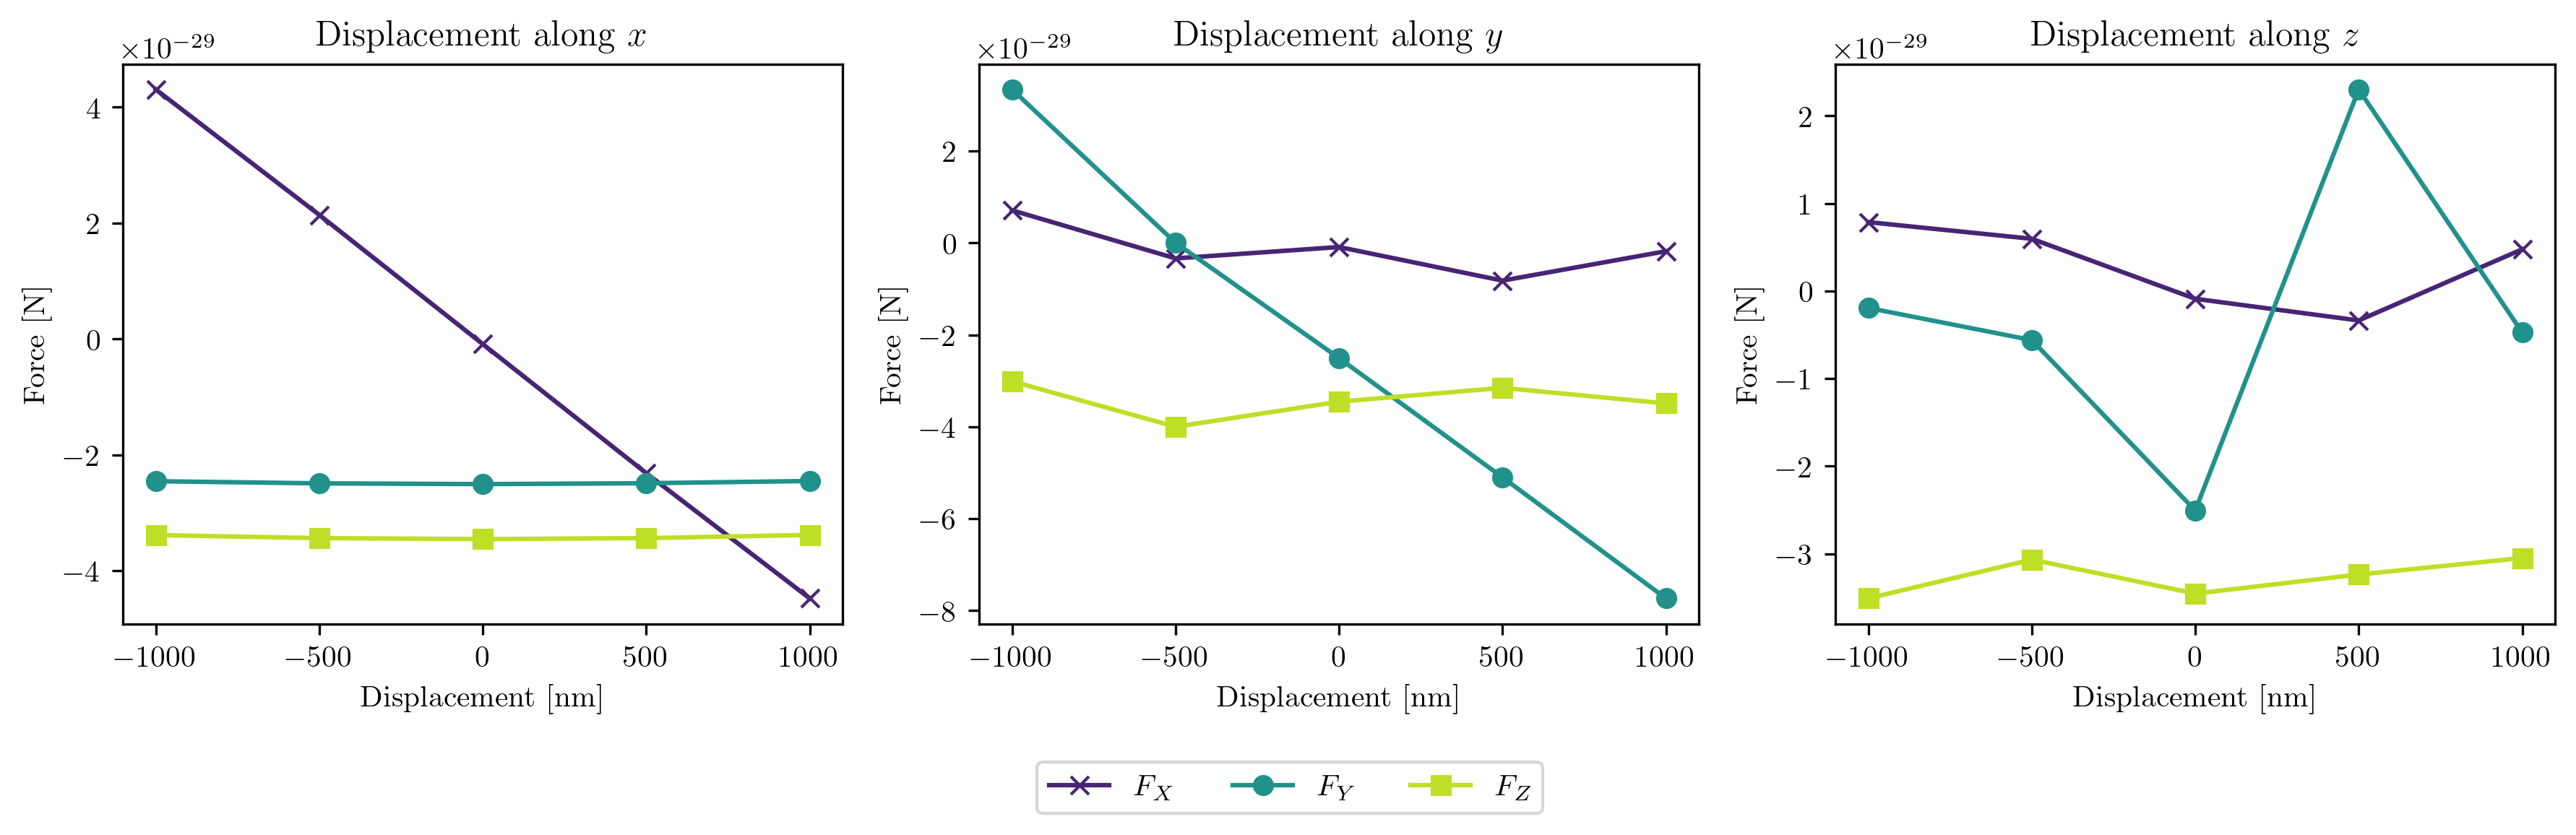

(<Figure size 3600x1140 with 3 Axes>,
 array([<Axes: title={'center': 'Displacement along $x$'}, xlabel='Displacement [nm]', ylabel='Force [N]'>,
        <Axes: title={'center': 'Displacement along $y$'}, xlabel='Displacement [nm]', ylabel='Force [N]'>,
        <Axes: title={'center': 'Displacement along $z$'}, xlabel='Displacement [nm]', ylabel='Force [N]'>],
       dtype=object))

In [5]:
Force = force_vs_displacement(geometry=geometry, step_nm=step_nm, material=material, efield=efield, dyads=dyads, displacements=DEFAULT_FORCE_DISPLACEMENTS_NM, field_index=field_index)
plot_force_displacement(displacements=DEFAULT_FORCE_DISPLACEMENTS_NM, Force=Force, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="force_vs_displacement", results_dir=results_dir)

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 175.0ms, inv.: 879.4ms, repropa.: 19.7ms (1 field configs), tot: 1074.3ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 85.6ms, inv.: 933.6ms, repropa.: 20.6ms (1 field configs), tot: 1039.9ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 92.1ms, inv.: 874.7ms, repropa.: 20.8ms (1 field configs), tot: 987.7ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 89.7ms, inv.: 858.9ms, repropa.: 19.3ms (1 field configs), tot: 968.0ms
structure initialization - automatic mesh detection: hex


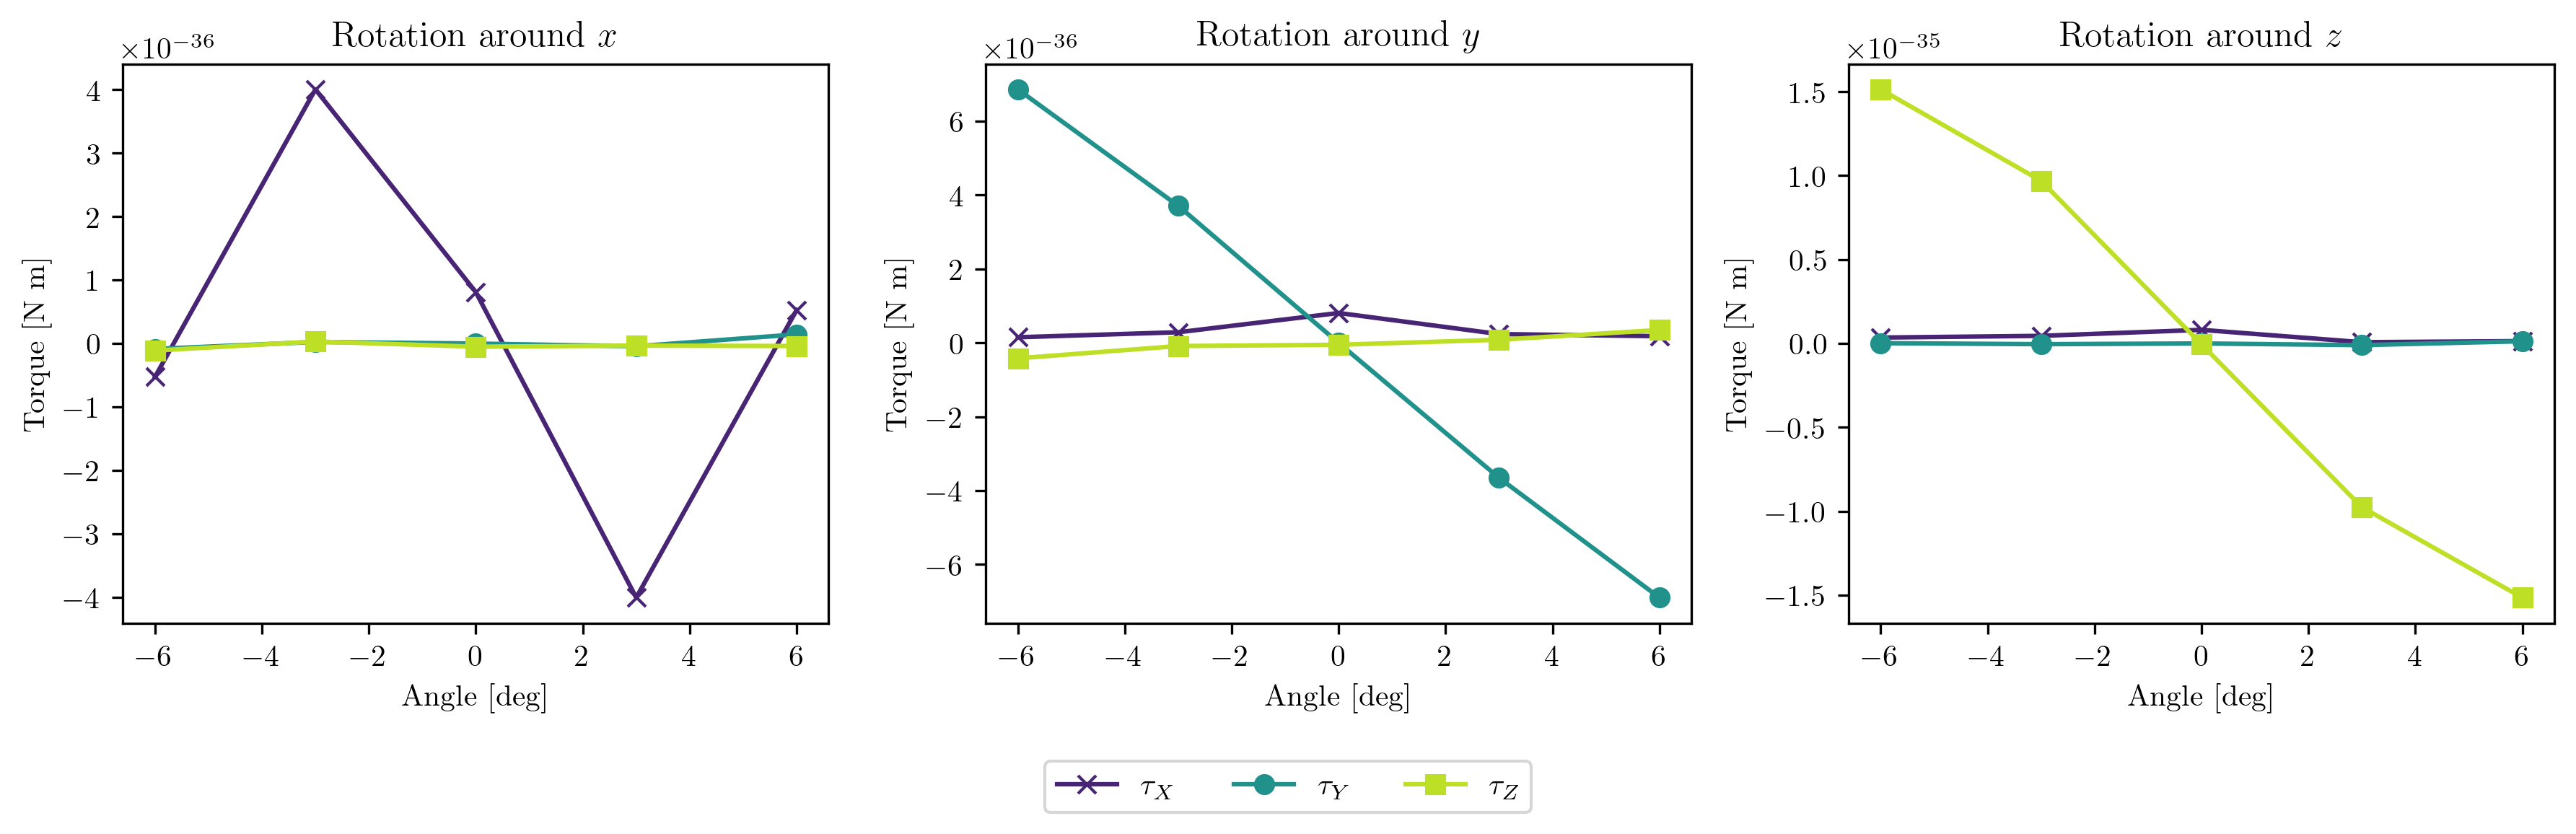

(<Figure size 3600x1140 with 3 Axes>,
 array([<Axes: title={'center': 'Rotation around $x$'}, xlabel='Angle [deg]', ylabel='Torque [N m]'>,
        <Axes: title={'center': 'Rotation around $y$'}, xlabel='Angle [deg]', ylabel='Torque [N m]'>,
        <Axes: title={'center': 'Rotation around $z$'}, xlabel='Angle [deg]', ylabel='Torque [N m]'>],
       dtype=object))

In [6]:
Torque = torque_vs_rotation(geometry=geometry, step_nm=step_nm, material=material, efield=efield, dyads=dyads, angles_deg=DEFAULT_ROTATION_ANGLES_DEG, field_index=field_index)
plot_torque_rotation(angles_deg=DEFAULT_ROTATION_ANGLES_DEG, Torque=Torque, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="torque_vs_rotation", results_dir=results_dir)